# Preparación de muestras de entrenamiento

Este notebook documenta la preparación de las muestras usadas para el entrenamiento de los modelos de clasificación de coberturas.

El proceso incluye:

- carga de los puntos de entrenamiento;
- revisión de columnas de clase;
- visualización de puntos por clase;
- conteo de muestras por clase;
- extracción de valores del raster reducido en los puntos;
- generación de matriz de variables predictoras y vector de clases;
- creación y guardado del split estratificado de entrenamiento y prueba.

El split generado en esta etapa será reutilizado en los notebooks posteriores para entrenamiento y evaluación.


In [1]:
from pathlib import Path
import sys

import pandas as pd

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml


## Importación de funciones auxiliares

Las funciones principales para preparar puntos, extraer muestras y generar el split se encuentran en:

`src/clasificacion_coberturas/muestras.py`

También se utiliza la lista de variables seleccionadas generada en `03_preparacion_raster.ipynb`.


In [3]:
from src.clasificacion_coberturas.preparacion_raster import cargar_lista_json

from src.clasificacion_coberturas.muestras import (
    cargar_puntos_entrenamiento,
    contar_clases,
    graficar_distribucion_clases,
    preparar_muestras_y_split
)

## Configuración de rutas

Se definen las rutas del raster reducido, la lista de variables seleccionadas y la capa de puntos de entrenamiento.

El raster reducido y el archivo JSON provienen del notebook `03_preparacion_raster.ipynb`.


In [4]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

year = 2018

ruta_raster_reducido = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "reducidos"
    / f"S2_REDUCIDO_PEARSON_{year}.tif"
)

ruta_bandas_json = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "reducidos"
    / f"bandas_pearson_{year}.json"
)

ruta_puntos = (
    BASE_DIR
    / "data"
    / "raw"
    / "clasificacion_coberturas"
    / "vectores"
    / "PUNTOS_N1.shp"
)

carpeta_muestras = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "muestras"
)

carpeta_splits = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "splits"
)

carpeta_figuras = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "clasificacion_coberturas"
)

print("Raster reducido:")
print(ruta_raster_reducido)

print("\nJSON de variables seleccionadas:")
print(ruta_bandas_json)

print("\nPuntos de entrenamiento:")
print(ruta_puntos)

print("\nCarpeta de muestras:")
print(carpeta_muestras)

print("\nCarpeta de splits:")
print(carpeta_splits)

Raster reducido:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\S2_REDUCIDO_PEARSON_2018.tif

JSON de variables seleccionadas:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\bandas_pearson_2018.json

Puntos de entrenamiento:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\raw\clasificacion_coberturas\vectores\PUNTOS_N1.shp

Carpeta de muestras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\muestras

Carpeta de splits:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits


## Configuración de columnas y split

La columna `Clase_N1` contiene el código numérico de clase usado como variable objetivo.

La columna `d_nivel_1_` contiene la etiqueta descriptiva de la clase y se usa para visualización y revisión.

El split se configura como estratificado para conservar, en lo posible, la proporción de clases en entrenamiento y prueba.


In [5]:
columna_clase = "Clase_N1"
columna_clase_nombre = "d_nivel_1_"

test_size = 0.3
random_state = 42
normalizar = True

ruta_muestras = carpeta_muestras / f"muestras_entrenamiento_{year}.csv"
ruta_split = carpeta_splits / f"split_clasificacion_{year}.joblib"

print("Columna de clase:", columna_clase)
print("Columna de nombre de clase:", columna_clase_nombre)
print("Test size:", test_size)
print("Random state:", random_state)
print("Normalizar raster:", normalizar)

print("\nRuta muestras:")
print(ruta_muestras)

print("\nRuta split:")
print(ruta_split)

Columna de clase: Clase_N1
Columna de nombre de clase: d_nivel_1_
Test size: 0.3
Random state: 42
Normalizar raster: True

Ruta muestras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\muestras\muestras_entrenamiento_2018.csv

Ruta split:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits\split_clasificacion_2018.joblib


## Carga de variables seleccionadas

Se carga la lista de variables seleccionadas en la etapa de preparación del raster.

Esta lista define las columnas esperadas en la matriz de entrenamiento.


In [6]:
variables_modelo = cargar_lista_json(ruta_bandas_json)

print("Número de variables del modelo:")
print(len(variables_modelo))

variables_modelo

Número de variables del modelo:
22


['B2',
 'B8',
 'B5',
 'B6',
 'NDVI',
 'EVI',
 'NDMI',
 'TEX_B2_contrast',
 'TEX_B2_ent',
 'TEX_B2_asm',
 'TEX_B2_corr',
 'TEX_B2_var',
 'TEX_B3_contrast',
 'TEX_B3_ent',
 'TEX_B3_corr',
 'TEX_B4_asm',
 'TEX_B4_corr',
 'TEX_B8_contrast',
 'TEX_B8_ent',
 'TEX_B8_corr',
 'TEX_B8_var',
 'TEX_B8_sent']

## Carga y revisión de puntos de entrenamiento

Se carga la capa de puntos y se revisan sus columnas principales.

Esta capa debe contener geometrías puntuales y los campos de clase definidos en la configuración.


In [7]:
gdf_puntos = cargar_puntos_entrenamiento(
    ruta_puntos=ruta_puntos,
    columna_clase=columna_clase,
    columna_clase_nombre=columna_clase_nombre
)

print("Puntos cargados:", len(gdf_puntos))
print("CRS:", gdf_puntos.crs)
print("Columnas:")
print(gdf_puntos.columns.tolist())

display(gdf_puntos.head())

Puntos cargados: 6101
CRS: GEOGCS["unknown",DATUM["D_Unknown_based_on_GRS_1980_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Columnas:
['d_nivel_1_', 'Clase_N1', 'Clase_N1M', 'geometry']


,d_nivel_1_,Clase_N1,Clase_N1M,geometry
0,BOSQUES Y AREAS SEMINATURALES,2.0,2.0,POINT (-74.09579 4.48526)
1,TERRITORIOS ARTIFICIALIZADOS,5.0,5.0,POINT (-74.09631 4.48664)
2,BOSQUES Y AREAS SEMINATURALES,2.0,2.0,POINT (-74.0956 4.48711)
3,TERRITORIOS ARTIFICIALIZADOS,5.0,5.0,POINT (-74.09591 4.48792)
4,TERRITORIOS ARTIFICIALIZADOS,5.0,5.0,POINT (-74.09578 4.488)


## Visualización interactiva de puntos por clase

Se visualizan los puntos de entrenamiento coloreados por clase descriptiva.

Esta visualización permite revisar la distribución espacial de las muestras antes de extraer los valores del raster.


In [8]:
mapa_puntos = gdf_puntos.explore(
    column=columna_clase_nombre,
    categorical=True,
    legend=True,
    cmap="tab10",
    tooltip=[columna_clase_nombre, columna_clase]
)

mapa_puntos

## Distribución de clases

Se calcula y visualiza el número de puntos disponibles por clase.

Esta revisión es importante para identificar posibles desbalances antes de entrenar los modelos.


,d_nivel_1_,conteo,codigo_clase
0,BOSQUES Y AREAS SEMINATURALES,2201,2.0
2,TERRITORIOS ARTIFICIALIZADOS,2200,5.0
1,SUPERFICIES DE AGUA,1700,3.0


Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\distribucion_clases_2018.png


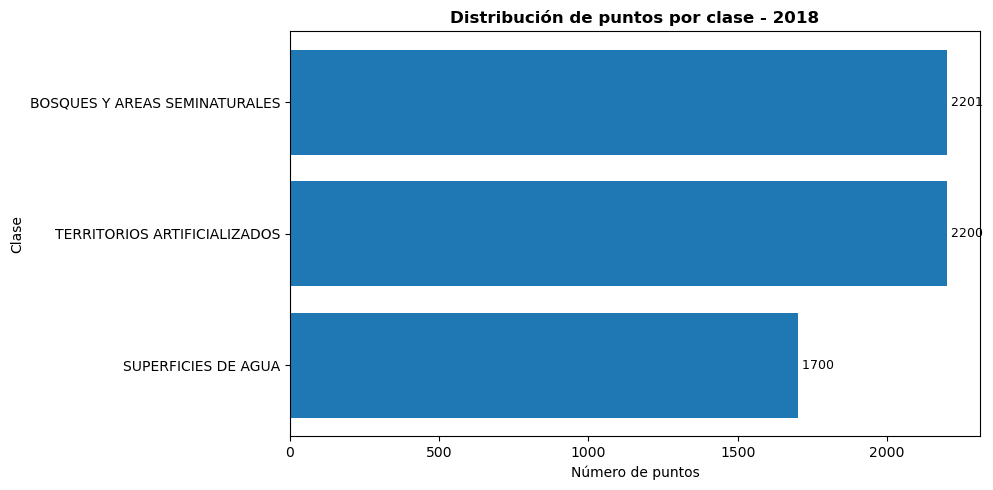

In [9]:
tabla_clases = contar_clases(
    gdf_puntos=gdf_puntos,
    columna_clase=columna_clase,
    columna_clase_nombre=columna_clase_nombre
)

display(tabla_clases)

ruta_figura_clases = carpeta_figuras / f"distribucion_clases_{year}.png"

graficar_distribucion_clases(
    tabla_clases=tabla_clases,
    ruta_figura=ruta_figura_clases,
    columna_nombre=columna_clase_nombre,
    columna_conteo="conteo",
    titulo=f"Distribución de puntos por clase - {year}"
)

## Extracción de muestras y creación del split

Se extraen los valores del raster reducido en cada punto de entrenamiento.

Luego se genera un split estratificado de entrenamiento y prueba, que se guarda en formato `.joblib` para ser reutilizado en las siguientes etapas.


In [10]:
resultados_muestras = preparar_muestras_y_split(
    ruta_raster=ruta_raster_reducido,
    ruta_puntos=ruta_puntos,
    ruta_muestras=ruta_muestras,
    ruta_split=ruta_split,
    variables_modelo=variables_modelo,
    columna_clase=columna_clase,
    columna_clase_nombre=columna_clase_nombre,
    normalizar=normalizar,
    test_size=test_size,
    random_state=random_state
)

X_points = resultados_muestras["X_points"]
y_points = resultados_muestras["y_points"]
df_muestras = resultados_muestras["df_muestras"]
X_train = resultados_muestras["X_train"]
X_test = resultados_muestras["X_test"]
y_train = resultados_muestras["y_train"]
y_test = resultados_muestras["y_test"]

print("Muestras preparadas correctamente.")
print("X_points:", X_points.shape)
print("y_points:", y_points.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

display(df_muestras.head())

Reproyectando puntos de GEOGCS["unknown",DATUM["D_Unknown_based_on_GRS_1980_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]] a EPSG:4326...
Puntos originales: 6101
Puntos válidos: 200
Puntos descartados: 5901
Shape X_points: (200, 22)
Shape y_points: (200,)
Muestras guardadas en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\muestras\muestras_entrenamiento_2018.csv
Split guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits\split_clasificacion_2018.joblib
Muestras preparadas correctamente.
X_points: (200, 22)
y_points: (200,)
X_train: (140, 22)
X_test: (60, 22)
y_train: (140,)
y_test: (60,)


,B2,B8,B5,B6,NDVI,EVI,NDMI,TEX_B2_contrast,TEX_B2_ent,TEX_B2_asm,...,TEX_B3_ent,TEX_B3_corr,TEX_B4_asm,TEX_B4_corr,TEX_B8_contrast,TEX_B8_ent,TEX_B8_corr,TEX_B8_var,TEX_B8_sent,Clase_N1
0,0.999961,0.999963,0.999974,0.999974,0.999981,0.999950,0.999961,0.958682,0.999858,0.999911,...,0.999854,0.999948,0.999978,0.999956,0.946040,0.999949,0.999975,0.902973,0.999923,2.0
1,0.999962,0.999963,0.999975,0.999976,0.999966,0.999946,0.999947,0.958163,0.999865,0.999911,...,0.999900,0.999987,0.999977,0.999981,0.949244,0.999960,0.999992,0.911172,0.999932,2.0
2,0.999962,0.999965,0.999975,0.999976,0.999961,0.999948,0.999961,0.958116,0.999815,0.999914,...,0.999858,0.999953,0.999978,0.999957,0.945777,0.999947,0.999984,0.903047,0.999930,2.0
3,0.999962,0.999967,0.999976,0.999978,0.999972,0.999952,0.999961,0.960655,0.999893,0.999910,...,0.999925,0.999964,0.999977,0.999963,0.948672,0.999970,0.999987,0.908636,0.999964,2.0
4,0.999962,0.999966,0.999977,0.999979,0.999961,0.999948,0.999953,0.959051,0.999869,0.999912,...,0.999900,0.999963,0.999978,0.999963,0.948250,0.999957,0.999988,0.907998,0.999956,2.0


## Verificación del split

Se revisa la distribución de clases en entrenamiento y prueba para verificar el comportamiento del split estratificado.


In [11]:
df_train = pd.DataFrame({columna_clase: y_train})
df_test = pd.DataFrame({columna_clase: y_test})

distribucion_split = (
    pd.concat(
        [
            df_train[columna_clase].value_counts().rename("train"),
            df_test[columna_clase].value_counts().rename("test")
        ],
        axis=1
    )
    .fillna(0)
    .astype(int)
    .sort_index()
)

display(distribucion_split)

,train,test
Clase_N1,,
2.0,70,30
5.0,70,30


## Producto de esta etapa

Al finalizar este notebook se generan:

- tabla de muestras extraídas desde el raster reducido;
- split estratificado de entrenamiento y prueba;
- figura de distribución de clases.

La tabla de muestras se guarda en:

`data/interim/clasificacion_coberturas/muestras/`

El split se guarda en:

`data/interim/clasificacion_coberturas/splits/`

## Siguiente etapa del flujo

Una vez generado el split, el siguiente paso consiste en entrenar y comparar modelos de clasificación.

Esta fase se documenta en:

`05_entrenamiento_modelos.ipynb`
